# XGBoost Hyperparameter Analysis — Almaty PM2.5

Documents the model configuration and validates that the chosen hyperparameters
are reasonable for this dataset size (~9,200 training rows, 27 features).

Contents:
1. Final model configuration
2. Feature importance (gain-based)
3. Learning curve (train size vs RMSE)
4. n_estimators sensitivity

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from src.features.pipeline import build_feature_matrix
from src.models.xgboost_model import _DEFAULT_PARAMS

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

MODELS_DIR = Path('../models')
HORIZON = 6
TRAIN_RATIO = 0.80

print('Final XGBoost hyperparameters:')
for k, v in _DEFAULT_PARAMS.items():
    print(f'  {k}: {v}')

Final XGBoost hyperparameters:
  n_estimators: 600
  learning_rate: 0.05
  max_depth: 6
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  reg_alpha: 0.1
  reg_lambda: 1.0
  random_state: 42
  n_jobs: -1
  verbosity: 0


## 2. Feature importance (gain-based)

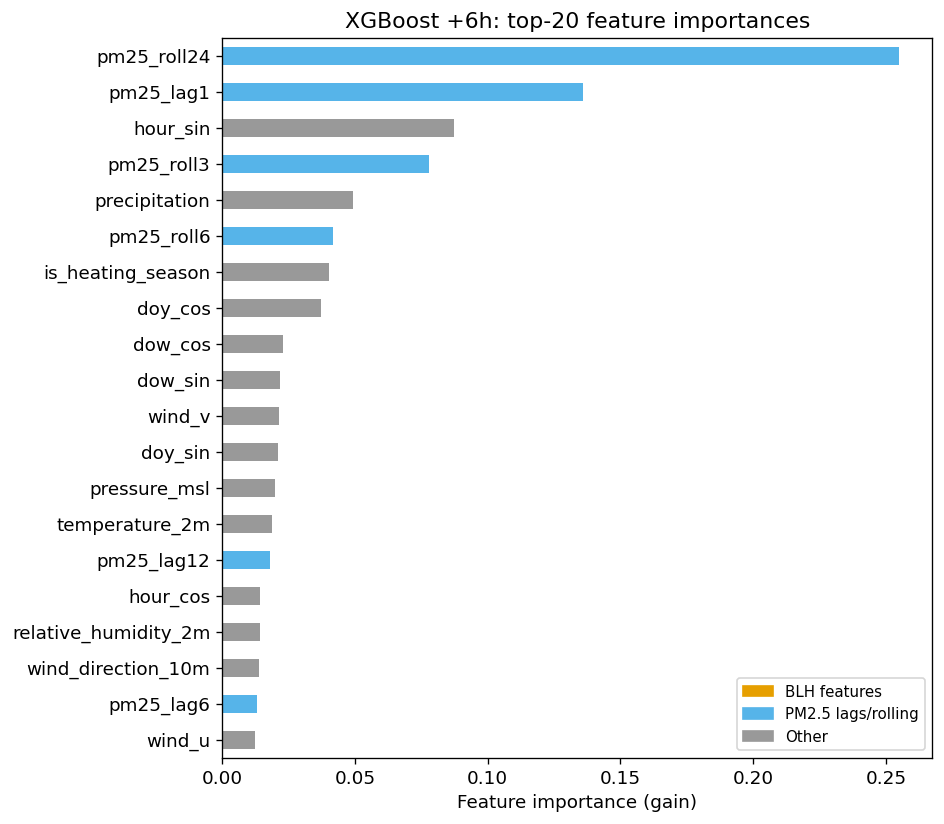

BLH features combined importance: 1.6% of total gain


In [2]:
feat_cols = json.loads((MODELS_DIR / 'feature_cols.json').read_text())
model = joblib.load(MODELS_DIR / 'xgb_h6.joblib')

importance = pd.Series(
    model.feature_importances_,
    index=feat_cols[:len(model.feature_importances_)]
).sort_values(ascending=True)

top20 = importance.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#E69F00' if 'blh' in c.lower() else
          '#56B4E9' if 'pm25' in c.lower() else '#999999'
          for c in top20.index]
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost +6h: top-20 feature importances')

from matplotlib.patches import Patch
legend = [Patch(color='#E69F00', label='BLH features'),
          Patch(color='#56B4E9', label='PM2.5 lags/rolling'),
          Patch(color='#999999', label='Other')]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

blh_feats = [c for c in feat_cols if 'blh' in c.lower()]
blh_total = importance.reindex(blh_feats).sum()
total = importance.sum()
print(f'BLH features combined importance: {blh_total/total*100:.1f}% of total gain')

## 3. Learning curve

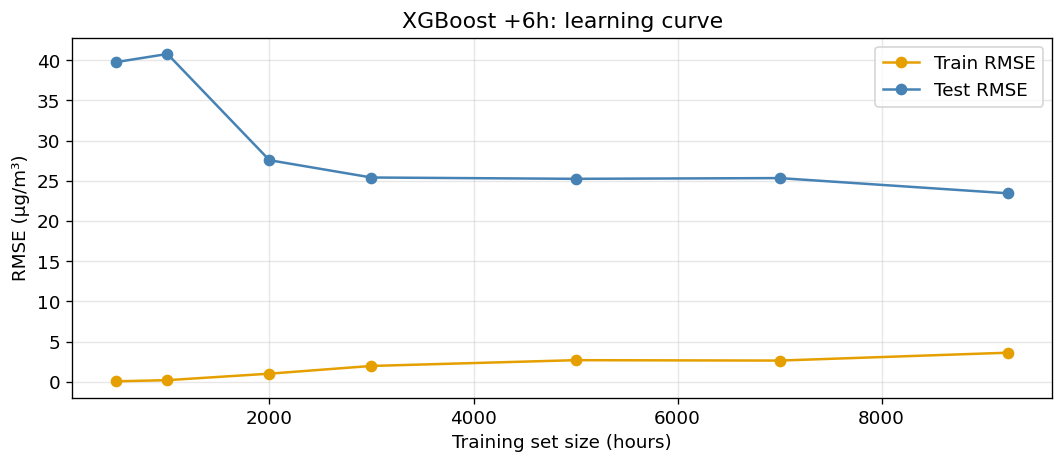

Final test RMSE at full training set (9,237 h): 23.44 μg/m³


In [3]:
from src.models.xgboost_model import train
from sklearn.metrics import mean_squared_error

df = build_feature_matrix()
target = f'pm25_h{HORIZON}'
df[target] = df['pm25'].shift(-HORIZON)
df = df.dropna(subset=[target])

split = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split]
test_df  = df.iloc[split:]

available = [c for c in feat_cols if c in df.columns]
X_test = test_df[available]
y_test = test_df[target].values

# Learning curve: vary training set size
sizes = [500, 1000, 2000, 3000, 5000, 7000, len(train_df)]
train_rmses, test_rmses = [], []

for s in sizes:
    sub = train_df.iloc[:s]
    m = train(sub[available], sub[target])
    train_rmses.append(np.sqrt(mean_squared_error(sub[target], m.predict(sub[available]))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, train_rmses, 'o-', color='#E69F00', label='Train RMSE')
ax.plot(sizes, test_rmses,  'o-', color='steelblue', label='Test RMSE')
ax.set_xlabel('Training set size (hours)')
ax.set_ylabel('RMSE (μg/m³)')
ax.set_title(f'XGBoost +{HORIZON}h: learning curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final test RMSE at full training set ({len(train_df):,} h): {test_rmses[-1]:.2f} μg/m³')

## 4. n_estimators sensitivity

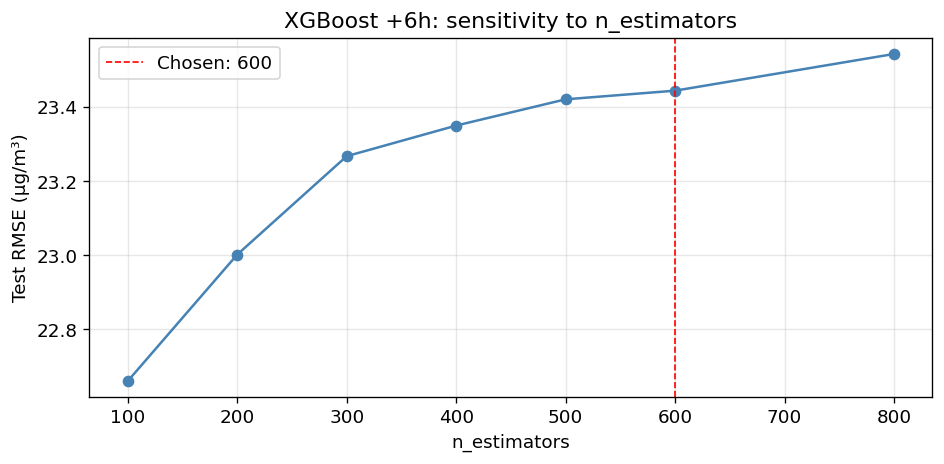

Best n_estimators: 100  (RMSE = 22.66)


In [4]:
from src.models.xgboost_model import _DEFAULT_PARAMS

X_train = train_df[available]
y_train = train_df[target]

n_list = [100, 200, 300, 400, 500, 600, 800]
test_rmses_n = []

for n in n_list:
    params = {**_DEFAULT_PARAMS, 'n_estimators': n}
    m = train(X_train, y_train, params=params)
    test_rmses_n.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_list, test_rmses_n, 'o-', color='steelblue')
ax.axvline(600, color='red', ls='--', lw=1, label='Chosen: 600')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Test RMSE (μg/m³)')
ax.set_title(f'XGBoost +{HORIZON}h: sensitivity to n_estimators')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n = n_list[np.argmin(test_rmses_n)]
print(f'Best n_estimators: {best_n}  (RMSE = {min(test_rmses_n):.2f})')